# LDT Analysis

corpus로 부터 추출한 단어들을 이욯해 진행한 LDT RT(Response Time) 회귀 파일입니다.
단어 자극은 각 corpus에서 
- KE에서 60개 
- SUBTLEX에서 60개 
추출했으며, 총 111개로 9개를 겹쳐서 뽑았습니다.

단어는 각 코퍼스에서 20%~80% percentile에서 균등하게 추출했습니다.

## lib import

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from scipy.stats import zscore, f_oneway, ttest_ind
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.formula.api as smf
import warnings
import os
import pandas as pd
from matplotlib import pyplot as plt
warnings.filterwarnings('ignore')

## File Path

In [24]:
# 파일 경로 확인.
proj_path = os.path.dirname(os.path.dirname(Path.cwd())) # proj path
LDT_file_path = os.path.join(proj_path, 'src','LDT-data') # LDT data path
lextale_path = os.path.join(proj_path, 'src', 'LexTALE(1128).xlsx')

# 단어 자극들 리스트 경로
SUBTLEX_target_path = os.path.join(proj_path, 'src','SUBTLEX_stimuli(60).xlsx') # SUBTLEX 
KE_target_path = os.path.join(proj_path, 'src','KE_stimuli(60).xlsx') # KE 

# ELP 정보들이 저장된 csv file path
elex_path = '/Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison/Corpora/E-lexicon-proj/English Lexicon Project Items.csv'

## Exp word Stimuli load

In [25]:
# target word list load
cols = ['Word','Length', 'KE_rank', 'SUBTLEX_rank', 'Zipf_KE', 'Zipf_SUBTLEX']

SUBTLEX_target_df = pd.read_excel(SUBTLEX_target_path)[cols]
KE_target_df = pd.read_excel(KE_target_path)[cols]

# column rename
SUBTLEX_target_df.rename(columns={'Word': 'Stimuli'}, inplace=True)
KE_target_df.rename(columns={'Word': 'Stimuli'}, inplace=True)
full_word_df = pd.concat((SUBTLEX_target_df, KE_target_df)).drop_duplicates(subset=['Stimuli'])

In [26]:
SUBTLEX_target_df.shape, KE_target_df.shape, full_word_df.shape

((60, 6), (60, 6), (111, 6))

# Participant behavior experiment results load

In [27]:
csv_list = [file for file in os.listdir(LDT_file_path) if file.endswith('.csv')]
print(f"수집된 참가자 : {csv_list.__len__()} 명")

수집된 참가자 : 62 명


In [44]:
# 함친 참가자 데이터 저장할 곳.
SUBTLEX_cumulative_df = None
KE_cumulative_df = None

for file in csv_list:
    
    data_df = pd.read_csv(os.path.join(LDT_file_path, file))
    data_df.drop(columns=['Unnamed: 54'], inplace=True)
    
    mask_target = data_df['TrialType'] == 'Target'
    SUBTLEX_mask = data_df['Stimuli'].isin(SUBTLEX_target_df['Stimuli'])
    KE_mask = data_df['Stimuli'].isin(KE_target_df['Stimuli'])
    SUBTLEX_df = data_df[mask_target & SUBTLEX_mask]
    KE_df = data_df[mask_target & KE_mask]
    
    if SUBTLEX_cumulative_df is None:
        SUBTLEX_cumulative_df = pd.merge(SUBTLEX_df, SUBTLEX_target_df, on='Stimuli', how='left')
        KE_cumulative_df = pd.merge(KE_df, KE_target_df, on='Stimuli', how='left')

    else:
        SUBTLEX_cumulative_df = pd.concat([SUBTLEX_cumulative_df, pd.merge(SUBTLEX_df, SUBTLEX_target_df, on='Stimuli', how='left')]).reset_index(drop=True)
        KE_cumulative_df = pd.concat([KE_cumulative_df, pd.merge(KE_df, KE_target_df, on='Stimuli', how='left')]).reset_index(drop=True)

In [45]:
SUBTLEX_cumulative_df.shape, KE_cumulative_df.shape

((3720, 59), (3720, 59))

dataframe에서 type 정리

In [46]:
SUBTLEX_cumulative_df['Participant'] = SUBTLEX_cumulative_df['Participant'].astype(str)
KE_cumulative_df['Participant'] = KE_cumulative_df['Participant'].astype(str)

SUBTLEX_cumulative_df['Stimuli'] = SUBTLEX_cumulative_df['Stimuli'].astype(str)
KE_cumulative_df['Stimuli'] = KE_cumulative_df['Stimuli'].astype(str)

In [47]:
# 파일명 error fixing.

column_mapping = {
    '6' : 'MB06',
    'mb03' : 'MB03',
    'MB004(Juhyeon)' : 'MB04',
    'MA33' : 'MB33',
    '51' : 'MB51',
    '64' : 'MB64',
}
SUBTLEX_cumulative_df['Participant'] = SUBTLEX_cumulative_df['Participant'].replace(column_mapping)
KE_cumulative_df['Participant'] = KE_cumulative_df['Participant'].replace(column_mapping)

In [48]:
SUBTLEX_cumulative_df['Participant'].unique()

array(['MB21', 'MB25', 'MB31', 'MB22', 'MB64', 'MB01', 'MB03', 'MB40',
       'MB34', 'MB20', 'MB06', 'MB63', 'MB49', 'MB61', 'MB62', 'MB38',
       'MB51', 'MB15', 'MB54', 'MB47', 'MB28', 'MB65', 'MB59', 'MB13',
       'MB52', 'MB10', 'MB33', 'MB24', 'MB50', 'MB41', 'MB29', 'MB11',
       'MB35', 'MB12', 'MB53', 'MB32', 'MB08', 'MB48', 'MB42', 'MB58',
       'MB27', 'MB45', 'MB30', 'MB26', 'MB05', 'MB39', 'MB09', 'MB23',
       'MB56', 'MB16', 'MB14', 'MB43', 'MB02', 'MB07', 'MB60', 'MB04',
       'MB36', 'MB19', 'MB55', 'MB37', 'MB17', 'MB18'], dtype=object)

In [49]:
KE_cumulative_df.head()

,Task,TrialType,Stimuli,CorrectResponse,StimulusType,thisN,thisTrialN,thisRepN,Trialnumb,LDT_key_resp.keys,...,expName,expVersion,psychopyVersion,frameRate,expStart,Length,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX
0,LDT,Target,come,l,word,0.0,0.0,0.0,7.0,l,...,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,4,27.419355,1.773168,5.873805,6.496436
1,LDT,Target,full,l,word,4.0,4.0,0.0,43.0,l,...,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,4,62.903226,17.263299,5.386682,5.221875
2,LDT,Target,area,l,word,7.0,7.0,0.0,49.0,l,...,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,4,69.153226,29.943125,5.307500,4.874079
3,LDT,Target,man,l,word,11.0,11.0,0.0,12.0,l,...,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,3,31.250000,2.709936,5.818737,6.265545
4,LDT,Target,long,l,word,14.0,14.0,0.0,6.0,l,...,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,4,25.806452,5.754433,5.898924,5.828787


In [50]:
KE_cumulative_df.columns

Index(['Task', 'TrialType', 'Stimuli', 'CorrectResponse', 'StimulusType',
       'thisN', 'thisTrialN', 'thisRepN', 'Trialnumb', 'LDT_key_resp.keys',
       'LDT_key_resp.corr', 'LDT_key_resp.rt', 'LDT_key_resp.duration',
       'LDT_prac_trials.thisRepN', 'LDT_prac_trials.thisTrialN',
       'LDT_prac_trials.thisN', 'LDT_prac_trials.thisIndex',
       'LDT_trials.thisRepN', 'LDT_trials.thisTrialN', 'LDT_trials.thisN',
       'LDT_trials.thisIndex', 'thisRow.t', 'notes', 'Intro.started',
       'Intro.stopped', 'LDT_intro.started', 'keyboard_LDT.started',
       'LDT_intro.stopped', 'LDT_prac.started', 'LDT_prac.stopped',
       'LDT_feedback.started', 'LDT_feedback.stopped', 'LDT_instr.started',
       'LDT_instr_key_resp.started', 'LDT_instr.stopped', 'LDT_trial.started',
       'LDT_stim_text.started', 'LDT_key_resp.started', 'LDT_trial.stopped',
       'LDT_trials.LDT_key_resp.keys', 'LDT_trials.LDT_key_resp.corr',
       'LDT_trials.LDT_key_resp.rt', 'LDT_trials.LDT_key_resp.durat

모든 단어들을 기준으로도 merge

## RT에 log-transformation, Zipf-frequency에 z-scoring

In [51]:
# z-scoring
KE_cumulative_df['Zipf_KE_z'] = zscore(KE_cumulative_df['Zipf_KE'])
KE_cumulative_df['Zipf_SUBTLEX_z'] = zscore(KE_cumulative_df['Zipf_SUBTLEX'])

SUBTLEX_cumulative_df['Zipf_KE_z'] = zscore(SUBTLEX_cumulative_df['Zipf_KE'])
SUBTLEX_cumulative_df['Zipf_SUBTLEX_z'] = zscore(SUBTLEX_cumulative_df['Zipf_SUBTLEX'])

# log-transformation RT
KE_cumulative_df['log_rt'] = np.log10(KE_cumulative_df['LDT_key_resp.rt'])
SUBTLEX_cumulative_df['log_rt'] = np.log10(SUBTLEX_cumulative_df['LDT_key_resp.rt'])

## 사용할 column만 load

In [52]:
# 살릴 columns
target_cols = ['Stimuli', 'Length', # stimuli info
              'Zipf_KE', 'Zipf_KE_z','Zipf_SUBTLEX','Zipf_SUBTLEX_z','KE_rank', 'SUBTLEX_rank', # frequency info
              'Participant', 'LDT_key_resp.rt','log_rt', 'LDT_trials.thisTrialN', 'LDT_trials.LDT_key_resp.corr', # experiment info
              ]

# rename columns
renamed_cols = {
    'LDT_key_resp.rt': 'rt',
    'LDT_trials.thisTrialN': 'trial_num',
    'LDT_trials.LDT_key_resp.corr': 'correctness',
    'KE_rank': 'rank_KE',
    'SUBTLEX_rank': 'rank_SUBTLEX',
}

KE_cumulative_df = KE_cumulative_df[target_cols]
KE_cumulative_df.rename(columns=renamed_cols, inplace=True)

SUBTLEX_cumulative_df = SUBTLEX_cumulative_df[target_cols]
SUBTLEX_cumulative_df.rename(columns=renamed_cols, inplace=True)

In [ ]:
SUBTLEX_cumulative_df.shape, KE_cumulative_df.shape

((3720, 13), (3720, 13), (6882, 13))

In [55]:
KE_cumulative_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Stimuli         3720 non-null   object 
 1   Length          3720 non-null   int64  
 2   Zipf_KE         3720 non-null   float64
 3   Zipf_KE_z       3720 non-null   float64
 4   Zipf_SUBTLEX    3720 non-null   float64
 5   Zipf_SUBTLEX_z  3720 non-null   float64
 6   rank_KE         3720 non-null   float64
 7   rank_SUBTLEX    3720 non-null   float64
 8   Participant     3720 non-null   object 
 9   rt              3720 non-null   float64
 10  log_rt          3720 non-null   float64
 11  trial_num       3720 non-null   float64
 12  correctness     3720 non-null   float64
dtypes: float64(10), int64(1), object(2)
memory usage: 377.9+ KB


# Merging LexTALE

loading lextale files

In [56]:
lextale_df = pd.read_excel(lextale_path)
lextale_df.head()

,참가자 번호,이름,점수,비고
0,MB01,이유승,48.75,근장
1,MB02,이여규,66.25,인턴
2,MB03,정유라,65,근장
3,MB04,박주현,73.75,나-실험자
4,MB05,유희상,60,인턴


In [57]:
KE_lex_score = []
for idx, item in KE_cumulative_df.iterrows():
    case_mask = lextale_df['참가자 번호'] == item.get('Participant')
    if case_mask.sum() == 0:
        raise ValueError(f"Participant {item.get('Participant')} not found in LexTALE")
    else:
        KE_lex_score.append(lextale_df[case_mask]['점수'].values[0])

KE_cumulative_df['LexTALE'] = KE_lex_score
KE_cumulative_df.head()


,Stimuli,Length,Zipf_KE,Zipf_KE_z,Zipf_SUBTLEX,Zipf_SUBTLEX_z,rank_KE,rank_SUBTLEX,Participant,rt,log_rt,trial_num,correctness,LexTALE
0,come,4,5.873805,1.310593,6.496436,2.310684,27.419355,1.773168,MB21,0.648006,-0.188421,0.0,1.0,67.5
1,full,4,5.386682,-0.662858,5.221875,-0.310166,62.903226,17.263299,MB21,0.398474,-0.399600,4.0,1.0,67.5
2,area,4,5.307500,-0.983641,4.874079,-1.025331,69.153226,29.943125,MB21,0.492005,-0.308031,7.0,1.0,67.5
3,man,3,5.818737,1.087499,6.265545,1.835909,31.250000,2.709936,MB21,0.527982,-0.277381,11.0,1.0,67.5
4,long,4,5.898924,1.412358,5.828787,0.937813,25.806452,5.754433,MB21,0.517990,-0.285678,14.0,1.0,67.5


In [58]:
SUBTLEX_lex_score = []
for idx, item in SUBTLEX_cumulative_df.iterrows():
    case_mask = lextale_df['참가자 번호'] == item.get('Participant')
    if case_mask.sum() == 0:
        raise ValueError(f"Participant {item.get('Participant')} not found in LexTALE")
    else:
        SUBTLEX_lex_score.append(lextale_df[case_mask]['점수'].values[0])

SUBTLEX_cumulative_df['LexTALE'] = SUBTLEX_lex_score
SUBTLEX_cumulative_df.head()

,Stimuli,Length,Zipf_KE,Zipf_KE_z,Zipf_SUBTLEX,Zipf_SUBTLEX_z,rank_KE,rank_SUBTLEX,Participant,rt,log_rt,trial_num,correctness,LexTALE
0,area,4,5.307500,1.272180,4.874079,1.150996,69.153226,29.943125,MB21,0.492005,-0.308031,7.0,1.0,67.5
1,rear,4,3.962267,-1.295479,4.094524,-1.667514,98.991935,78.889261,MB21,0.677960,-0.168796,12.0,1.0,67.5
2,trick,5,4.372441,-0.512575,4.674134,0.428086,96.774194,41.284711,MB21,0.566285,-0.246965,15.0,1.0,67.5
3,raise,5,4.789267,0.283023,4.741461,0.671511,90.927419,37.336902,MB21,0.496393,-0.304174,24.0,1.0,67.5
4,mass,4,4.857531,0.413320,4.236650,-1.153650,89.314516,71.194379,MB21,0.426559,-0.370020,26.0,1.0,67.5


In [66]:
full_cumulative_df = pd.concat((KE_cumulative_df, SUBTLEX_cumulative_df)).drop_duplicates(subset=['Stimuli', 'Participant'])
full_cumulative_df = full_cumulative_df.reset_index(drop=True)
full_cumulative_df

,Stimuli,Length,Zipf_KE,Zipf_KE_z,Zipf_SUBTLEX,Zipf_SUBTLEX_z,rank_KE,rank_SUBTLEX,Participant,rt,log_rt,trial_num,correctness,LexTALE
0,come,4,5.873805,1.310593,6.496436,2.310684,27.419355,1.773168,MB21,0.648006,-0.188421,0.0,1.0,67.5
1,full,4,5.386682,-0.662858,5.221875,-0.310166,62.903226,17.263299,MB21,0.398474,-0.399600,4.0,1.0,67.5
2,area,4,5.307500,-0.983641,4.874079,-1.025331,69.153226,29.943125,MB21,0.492005,-0.308031,7.0,1.0,67.5
3,man,3,5.818737,1.087499,6.265545,1.835909,31.250000,2.709936,MB21,0.527982,-0.277381,11.0,1.0,67.5
4,long,4,5.898924,1.412358,5.828787,0.937813,25.806452,5.754433,MB21,0.517990,-0.285678,14.0,1.0,67.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6877,strip,5,3.895320,-1.423261,4.195533,-1.302310,99.193548,73.636668,MB18,0.854362,-0.068358,207.0,1.0,75.0
6878,slim,4,3.719229,-1.759367,4.074170,-1.741103,99.596774,79.859485,MB18,0.513416,-0.289531,210.0,1.0,75.0
6879,boom,4,3.816139,-1.574395,4.338215,-0.786440,99.395161,64.603546,MB18,0.565379,-0.247660,216.0,1.0,75.0
6880,pack,4,4.459591,-0.346231,4.641235,0.309138,95.967742,43.593175,MB18,0.402979,-0.394718,219.0,1.0,75.0


# 자극 합쳐서 모든 Stimuli 대상 reg

In [67]:
full_cumulative_df

,Stimuli,Length,Zipf_KE,Zipf_KE_z,Zipf_SUBTLEX,Zipf_SUBTLEX_z,rank_KE,rank_SUBTLEX,Participant,rt,log_rt,trial_num,correctness,LexTALE
0,come,4,5.873805,1.310593,6.496436,2.310684,27.419355,1.773168,MB21,0.648006,-0.188421,0.0,1.0,67.5
1,full,4,5.386682,-0.662858,5.221875,-0.310166,62.903226,17.263299,MB21,0.398474,-0.399600,4.0,1.0,67.5
2,area,4,5.307500,-0.983641,4.874079,-1.025331,69.153226,29.943125,MB21,0.492005,-0.308031,7.0,1.0,67.5
3,man,3,5.818737,1.087499,6.265545,1.835909,31.250000,2.709936,MB21,0.527982,-0.277381,11.0,1.0,67.5
4,long,4,5.898924,1.412358,5.828787,0.937813,25.806452,5.754433,MB21,0.517990,-0.285678,14.0,1.0,67.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6877,strip,5,3.895320,-1.423261,4.195533,-1.302310,99.193548,73.636668,MB18,0.854362,-0.068358,207.0,1.0,75.0
6878,slim,4,3.719229,-1.759367,4.074170,-1.741103,99.596774,79.859485,MB18,0.513416,-0.289531,210.0,1.0,75.0
6879,boom,4,3.816139,-1.574395,4.338215,-0.786440,99.395161,64.603546,MB18,0.565379,-0.247660,216.0,1.0,75.0
6880,pack,4,4.459591,-0.346231,4.641235,0.309138,95.967742,43.593175,MB18,0.402979,-0.394718,219.0,1.0,75.0


# EDA

<Axes: xlabel='LexTALE', ylabel='Count'>

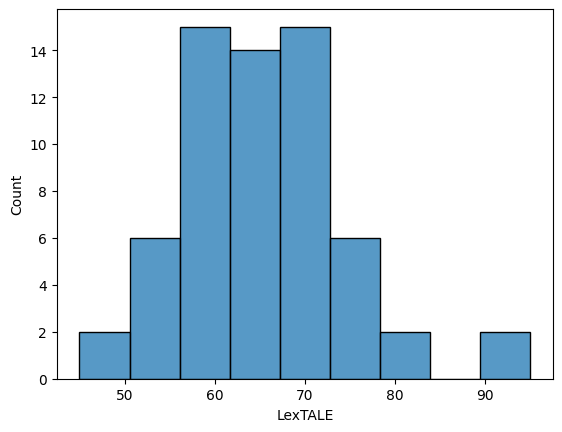

In [68]:
sns.histplot(full_cumulative_df.groupby('Participant')['LexTALE'].mean())

# Model Fitting

regression을 해서 KE, SUBTLEX에서 추출한 빈도가 얼마나 L2 English Learner의 behavior experiment data를 잘 설명하는 지 비교.

## Metrics

### Standardized Beta($\beta$)

- Raw frequency data는 심하게 Right-skewed(정적 편향) 되어 있어, 소수의 고빈도 단어가 소수의 고빈도 단어가 회귀선에 과도한 영향(High leverage)을 미치며 정규성 가정을 위배한다. 이에 Log-transformation을 적용하여 데이터 분포를 정규 분포에 가깝게 만들고(Normalization), 인간의 인지 처리가 자극 강도의 로그에 비례한다는 **베버-페히너 법칙(Weber-Fechner Law)**에 따라 빈도와 RT 간의 관계를 선형화(Linearize) 함.(Zipf-scaling)

- log-transform은 위의 분포 모양의 문제를 해결해주지만, 평균과 분산까지 맞춰주지는 못해, Zipf-scaling만 된 분포 자체로 회귀 시에 coeff 간 직접적인 비교 불가. 따라서 둘다 Z-scoring을 해줌.(Standardization)

### marginal $R^2$, conditional $R^2$

- Mixed Linear Effects Model의 경우, 개인차에 해당하는 분산 등 여러 변산을 통제해줘서 기존의 OLS(Ordinary Least Square)에서 사용하는 $R^2$ 를 사용하는 것은 타당하지 않음. 대안으로 제시된 개념이 marginal $R^2$랑 conditional $R^2$임.from Nakagawa & Schielzeth (2013)

- marginal $R^2$ : 모델의 **고정 효과(Fixed Effects)**만이 설명하는 분산의 비율
$$R^2_m = \frac{\sigma^2_{fixed}}{\sigma^2_{fixed} + \sigma^2_{random} + \sigma^2_{residual}}$$
- conditional $R^2$ : 모델의 고정 효과(Fixed Effects)와 랜덤 효과(Random Effects)를 모두 합쳐서 설명하는 분산의 비율
$$R^2_c = \frac{\sigma^2_{fixed} + \sigma^2_{random}}{\sigma^2_{fixed} + \sigma^2_{random} + \sigma^2_{residual}}$$

conditional $R^2$ 는 개인차를 고려하여 데이터의 변산성이 얼마나 설명되는지 말하는 개념이라 marginal $R^2$ 보다 일반적으로 값이 높음.
즉, 개인차에 대한 정보가 인지에서 꽤 크게 작용하는 것.

python에서 사용하는 statsmodel에서는 구현되어 있지 않고 보통 구현해서 쓰는 게 현재까진 일반적이라고 함. 구현은 아래에 mixedlm_r2 참조.

### AIC, BIC

보통 AI part에서 모델의 효율성을 설명하는데 많이 쓰이는 지표.
"데이터를 몇 % 설명하느냐"보다는 **"어떤 모델이 더 효율적인가"**를 판단할 때 사용.
코퍼스 연구에서 사용한다면, 수식 상 모델 구조를 통일시켜두고 본다면, likelihood 비교라, 코퍼스 질을 그대로 반영했다고 해석할 수도 있다.

#### AIC (Akaike Information Criterion)
$$AIC = -2\ln(L) + 2k$$
L : Likelihood, K: model_parameter number
- 정의: 모델의 적합도(Likelihood)를 높이면서 변수 개수(Complexity)에 대한 페널티를 부여한 값입니다.
- 설명: 값이 작을수록 더 좋은 모델입니다.
- 활용: 변수를 추가했을 때 모델이 개선되었는지 판단할 때 사용합니다. (예: stage4 공변량을 넣은 모델 vs 안 넣은 모델 비교)

#### BIC (Bayesian Information Criterion)
- 정의: AIC와 비슷하지만, 데이터 샘플 수($n$)가 많을수록 페널티를 더 강하게 줍니다.
- 설명: AIC보다 더 보수적이며, 값이 작을수록 좋습니다.
- 활용: 너무 복잡한 모델을 피하고 싶을 때(과적합 방지) 참고합니다.

In [69]:
import numpy as np

def mixedlm_r2(res):
    """
    res: fitted statsmodels MixedLMResults object
    Returns: dict with 'var_fixed', 'var_random', 'var_resid', 'R2_marginal', 'R2_conditional'
    """
    # 1) fixed effects linear predictor for each observation
    # exog: design matrix for fixed effects
    X = res.model.exog  # (n_obs x k)
    fe = res.fe_params.values.reshape(-1, 1)  # (k x 1)
    linpred = X.dot(fe).flatten()
    var_fixed = np.var(linpred, ddof=0)

    # 2) random effect variances
    # a) group-level random effects (from cov_re)
    var_random = 0.0
    try:
        # cov_re can be a matrix; if random intercept only, cov_re is 1x1
        cov_re = res.cov_re  # numpy array or DataFrame-like
        # sum diagonal elements (variances) of cov_re for random effects per group
        var_random += np.trace(np.atleast_2d(cov_re))
    except Exception:
        # if attribute not present, ignore
        pass

    # b) variance components from vc_formula (if any)
    try:
        # res.vcomp is array of variance components in statsmodels
        vcomp = np.asarray(res.vcomp)  # may be empty
        if vcomp.size > 0:
            var_random += vcomp.sum()
    except Exception:
        pass

    # 3) residual variance (scale)
    var_resid = float(res.scale)  # residual variance estimate

    # 4) total variance
    var_total = var_fixed + var_random + var_resid

    R2_marginal = var_fixed / var_total
    R2_conditional = (var_fixed + var_random) / var_total

    return {
        'var_fixed': var_fixed,
        'var_random': var_random,
        'var_resid': var_resid,
        'var_total': var_total,
        'R2_marginal': R2_marginal,
        'R2_conditional': R2_conditional
    }

In [99]:
def regression_plot_mixedlm(model, data, x_col, y_col, interaction_col=None, 
                            show_data=True, figsize=(10, 6), n_points=100, title=None):
    """
    MixedLM 모델의 회귀선을 그리는 함수
    
    Parameters:
    -----------
    model : statsmodels MixedLMResults
        적합된 MixedLM 모델
    data : pandas.DataFrame
        원본 데이터
    x_col : str
        x축 변수명 (주 예측 변수)
    y_col : str
        y축 변수명 (종속 변수)
    interaction_col : str, optional
        상호작용 변수명 (None이면 one-way, 지정하면 two-way)
    show_data : bool, default=True
        실제 데이터 포인트 표시 여부
    figsize : tuple, default=(10, 6)
        그래프 크기
    n_points : int, default=100
        예측선을 그릴 때 사용할 점의 개수
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Seaborn 스타일 설정
    sns.set_style("whitegrid")
    
    # 계수 추출
    fe_params = model.fe_params
    intercept = fe_params.get('Intercept', fe_params.get('Intercept', 0))
    
    # x 범위 생성
    x_min = data[x_col].min()
    x_max = data[x_col].max()
    x_range = np.linspace(x_min, x_max, n_points)
    
    # 그래프 생성
    fig, ax = plt.subplots(figsize=figsize)
    
    # 실제 데이터 포인트 표시 (옵션)
    if show_data:
        ax.scatter(data[x_col], data[y_col], 
                  alpha=0.3, s=20, color='gray', label='Observed data', zorder=1)
    
    # One-way (interaction 없음)
    if interaction_col is None:
        # x_col 계수 추출
        slope = fe_params.get(x_col, 0)
        y_pred = intercept + slope * x_range
        
        ax.plot(x_range, y_pred, 'b-', linewidth=2.5, label='Fitted line', zorder=2)
    
    # Two-way (interaction 있음)
    else:
        # 계수 추출
        coef_x = fe_params.get(x_col, 0)
        coef_interaction = fe_params.get(x_col, 0)  # 기본값
        
        # interaction term 이름 찾기 (두 가지 형식 가능: 'x:y' 또는 'x*y')
        interaction_terms = [key for key in fe_params.index if ':' in key or '*' in key]
        interaction_term = None
        
        # x_col과 interaction_col을 포함하는 interaction term 찾기
        for term in interaction_terms:
            if x_col in term and interaction_col in term:
                interaction_term = term
                break
        
        if interaction_term:
            coef_interaction = fe_params.get(interaction_term, 0)
        else:
            # 직접 조합 시도
            for sep in [':', '*']:
                term = f"{x_col}{sep}{interaction_col}"
                if term in fe_params.index:
                    coef_interaction = fe_params[term]
                    break
        
        # interaction_col의 계수 (없을 수도 있음)
        coef_interaction_var = fe_params.get(interaction_col, 0)
        
        # interaction_col의 특정 값들 (평균, -1SD, +1SD)
        if interaction_col in data.columns:
            interaction_mean = data[interaction_col].mean()
            interaction_std = data[interaction_col].std()
            interaction_values = [
                interaction_mean - interaction_std,
                interaction_mean,
                interaction_mean + interaction_std
            ]
            interaction_labels = [
                f'Low {interaction_col} (-1SD)',
                f'Mean {interaction_col}',
                f'High {interaction_col} (+1SD)'
            ]
        else:
            # interaction_col이 데이터에 없으면 모델의 계수만 사용
            interaction_values = [0]
            interaction_labels = ['Fitted line']
            coef_interaction_var = 0
        
        # 각 interaction_col 값에 대해 선 그리기
        colors = ['blue', 'green', 'red']
        for i, (inter_val, label) in enumerate(zip(interaction_values, interaction_labels)):
            y_pred = (intercept + 
                     coef_x * x_range + 
                     coef_interaction_var * inter_val + 
                     coef_interaction * x_range * inter_val)
            
            color = colors[i % len(colors)]
            ax.plot(x_range, y_pred, color=color, linewidth=2.5, 
                   label=label, zorder=2)
    
    # 그래프 설정
    ax.set_xlabel(x_col, fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    
    if interaction_col:
        if title is None:
            title = f'MixedLM: {x_col} × {interaction_col} Interaction'
        else:
            title = f'{title} (MixedLM: {x_col} × {interaction_col} Interaction)'
    else:
        if title is None:
            title = f'MixedLM: {x_col} Regression'
        else:
            title = f'{title} (MixedLM: {x_col} Regression)'
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, ax

# Q. 어떠한 코퍼스 빈도가 L2 RT 데이터를 잘 설명하는가?

## RT regression by Frequency

In [163]:
from typing import Dict, List

def eval_rt_frequency_reg(data : pd.DataFrame, 
                            dependent_var : str, 
                            independent_vars : List[str], groups : str = 'Participant',
                            vc_formula : Dict[str, str] = { "word": "0 + C(Stimuli)" }, 
                            re_formula : str = '~1', # random effect,
                            title : str = None
                            ):
    
    # model eval metric : AIC, BIC, NLL, marginal $R^2$, conditional $R^2$
    aics = []
    bics = []
    nlls = []
    marginal_r2s = []
    conditional_r2s = []

    for independent_var in independent_vars:
        formula = f'{dependent_var} ~ {independent_var}' # regression formula

        model = MixedLM.from_formula(formula,
            data=data, 
            groups=groups,
            vc_formula=vc_formula,
            re_formula=re_formula
            ).fit(reml=False)

        aics.append(model.aic)
        bics.append(model.bic)
        nlls.append(model.llf)
        marginal_r2s.append(mixedlm_r2(model)['R2_marginal'])
        conditional_r2s.append(mixedlm_r2(model)['R2_conditional'])
    print("================================")
    print('model eval metric')
    print("--------------------------------")
    print(pd.DataFrame({'independent_var': independent_vars, 'AIC': aics, 'BIC': bics, 'NLL': nlls, 'marginal_r2': marginal_r2s, 'conditional_r2': conditional_r2s}))
    print("================================")
    print()
    
    # eval metric standardized beta
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['red', 'blue']

    standardized_betas = []
    for idx, independent_var in enumerate(independent_vars):
        formula = f'{dependent_var} ~ {independent_var}_z' # regression formula

        model = MixedLM.from_formula(formula,
            data=data, 
            groups=groups,
            vc_formula=vc_formula,
            re_formula=re_formula
            ).fit(reml=False)
        
        print("--- Statsmodels를 이용한 MixedLM 결과 ---")
        print(f'formula: {formula}')
        print(model.summary())

        intercept = model.params['Intercept']
        slope = model.params[independent_var + '_z']
        x_min = data[independent_var + '_z'].min()
        x_max = data[independent_var + '_z'].max()
        x_range = np.linspace(x_min, x_max, 100)
        y_pred = (intercept + slope * x_range)
        ax.plot(x_range, y_pred, color=colors[idx], linewidth=2.5)

        ax.scatter(data[independent_var + '_z'], data[dependent_var], alpha=0.1, s=20, color=colors[idx], label=independent_var, zorder=1)

    if title is not None:
        ax.set_title(f'{title} log_rt ~ Zipf_Freq_z')
    else:
        ax.set_title(f'log_rt ~ Zipf_Freq_z')
    ax.legend()
    ax.set_xlabel('Zipf_Freq_z')
    ax.set_ylabel('log_rt')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

### Full Stimuli

- AIC, BIC, NLL이 무조건 낮을수록 fittin이 잘 된 것. 즉, 코퍼스의 예측력이 좋다.
- conditional, marginal $R^2$는 클수록 variance explain이 잫 된다는 의미
- standardized $beta$는 절댓값이 클수록 더 선형적인 관계라는 걸 의미

#### AIC, BIC, NLL, marginal $R^2$, conditional $R^2$

4가지 지표 모두 KE 빈도가 잘 RT를 잘 설명한다고 지지

#### Standardized $\beta$

위의  모든 지표를 포함해서, coeff, Standardized $\beta$ 역시 KE가 더 잘 설명.(slope이 KE에서 더 크게 관찰됨.)

model eval metric
--------------------------------
  independent_var           AIC           BIC          NLL  marginal_r2  \
0    Zipf_SUBTLEX -10135.375041 -10101.191718  5072.687520     0.042942   
1         Zipf_KE -10328.383332 -10294.200009  5169.191666     0.064405   

   conditional_r2  
0        0.660682  
1        0.668661  

--- Statsmodels를 이용한 MixedLM 결과 ---
formula: log_rt ~ Zipf_SUBTLEX_z
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   6882     Method:              ML       
No. Groups:         62       Scale:               0.0059   
Min. group size:    111      Log-Likelihood:      4920.7517
Max. group size:    111      Converged:           Yes      
Mean group size:    111.0                                  
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Inte

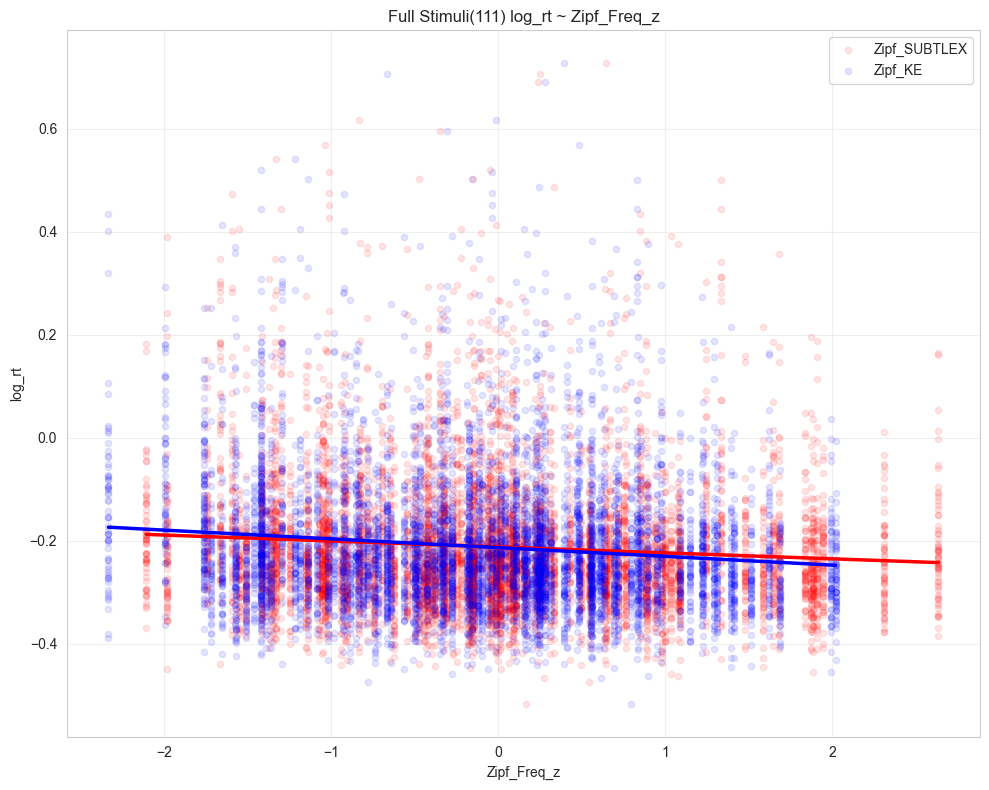

In [164]:
eval_rt_frequency_reg(full_cumulative_df, 'log_rt', ['Zipf_SUBTLEX', 'Zipf_KE'], title='Full Stimuli(111)')

### SUBTLEX Stimuli

#### AIC, BIC, NLL, marginal $R^2$, conditional $R^2$

마찬가지로, 모든 지표에서 KE가 더 잘 설명함.

#### Standardized $\beta$

SUBTLEX에서 기원한 자극이어도 KE의 빈도 효과가 더 크게 관찰된다.

model eval metric
--------------------------------
  independent_var          AIC          BIC          NLL  marginal_r2  \
0    Zipf_SUBTLEX -4915.593931 -4884.486536  2462.796965     0.020549   
1         Zipf_KE -4964.667585 -4933.560190  2487.333792     0.030717   

   conditional_r2  
0        0.654436  
1        0.658262  

--- Statsmodels를 이용한 MixedLM 결과 ---
formula: log_rt ~ Zipf_SUBTLEX_z
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   3720     Method:              ML       
No. Groups:         62       Scale:               0.0066   
Min. group size:    60       Log-Likelihood:      2462.7970
Max. group size:    60       Converged:           Yes      
Mean group size:    60.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept 

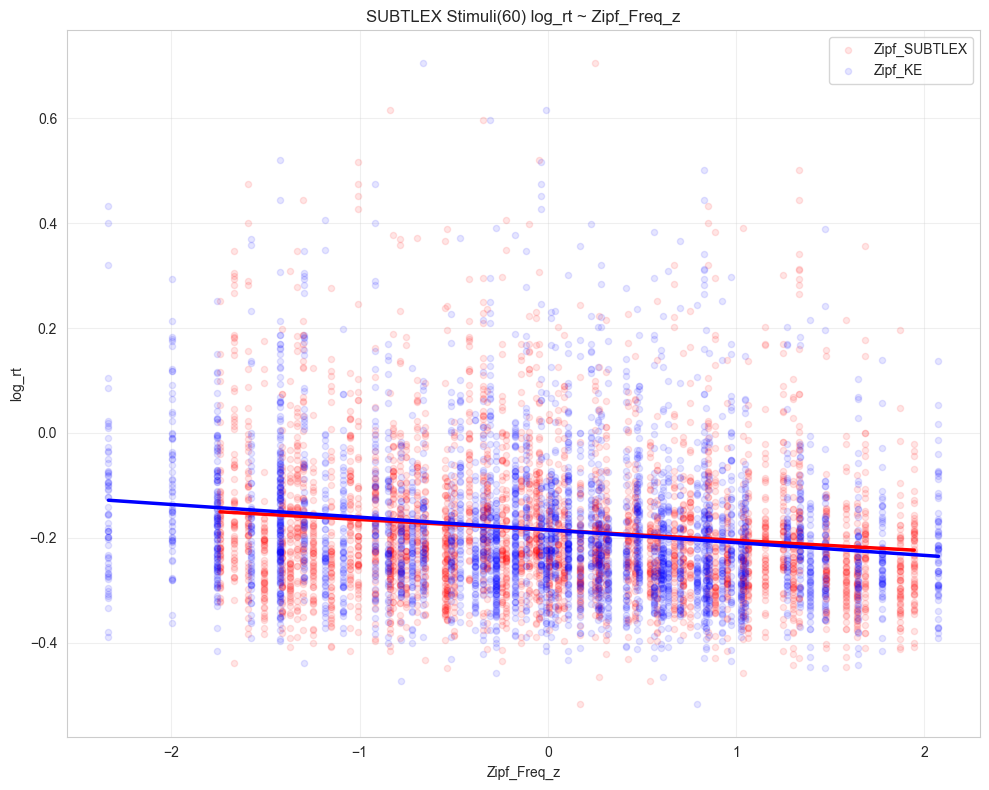

In [165]:
eval_rt_frequency_reg(SUBTLEX_cumulative_df, 'log_rt', ['Zipf_SUBTLEX', 'Zipf_KE'], title='SUBTLEX Stimuli(60)')

### KE Stiumli(60)

#### AIC, BIC, NLL, marginal $R^2$, conditional $R^2$

#### Standardized $\beta$

model eval metric
--------------------------------
  independent_var          AIC          BIC          NLL  marginal_r2  \
0    Zipf_SUBTLEX -6434.896907 -6403.789512  3222.448453     0.001187   
1         Zipf_KE -6439.571467 -6408.464072  3224.785733     0.002195   

   conditional_r2  
0        0.646461  
1        0.646838  

--- Statsmodels를 이용한 MixedLM 결과 ---
formula: log_rt ~ Zipf_SUBTLEX_z
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   3720     Method:              ML       
No. Groups:         62       Scale:               0.0044   
Min. group size:    60       Log-Likelihood:      3222.4485
Max. group size:    60       Converged:           Yes      
Mean group size:    60.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept 

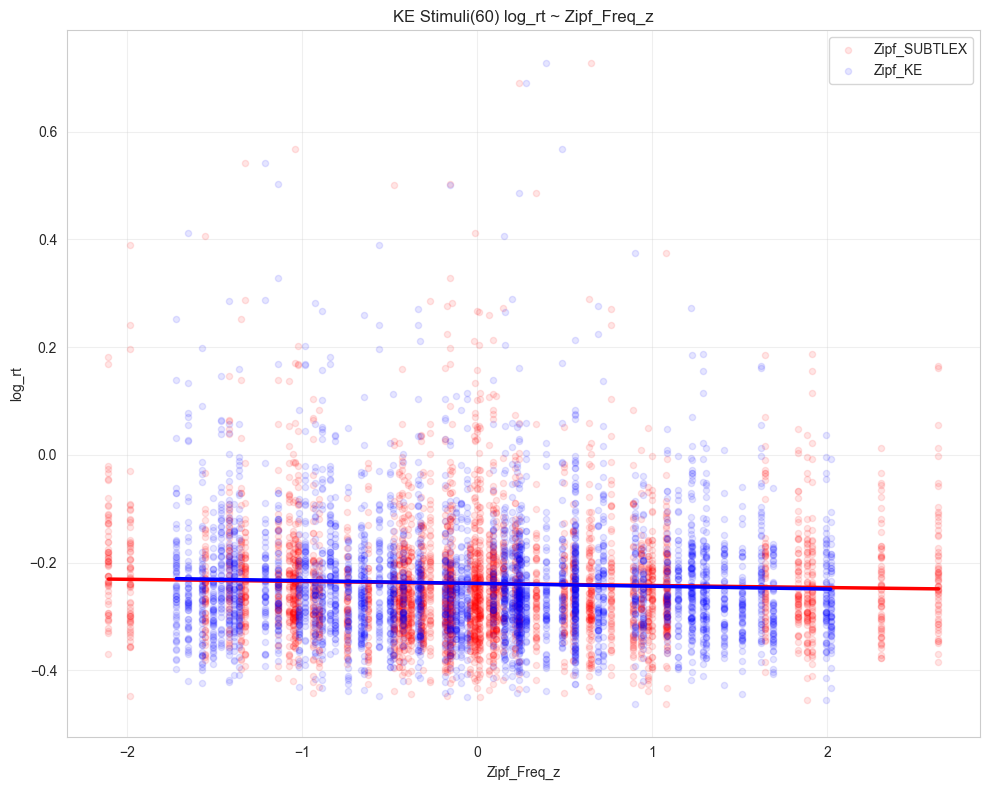

In [166]:
eval_rt_frequency_reg(KE_cumulative_df, 'log_rt', ['Zipf_SUBTLEX', 'Zipf_KE'], title='KE Stimuli(60)')

## RT regression by Frequency and LexTALE

여전히 대부분의 기울기는 KE가 더 좋은 예측력을 보여주고, 특이점은 LexTALE이 합쳐지니, 

In [176]:
from typing import Dict, List

def eval_rt_frequency_with_lextale_reg(data : pd.DataFrame, 
                            dependent_var : str, 
                            independent_vars : List[str], groups : str = 'Participant',
                            vc_formula : Dict[str, str] = { "word": "0 + C(Stimuli)" }, 
                            re_formula : str = '~1', # random effect,
                            title : str = None
                            ):
    
    # model eval metric : AIC, BIC, NLL, marginal $R^2$, conditional $R^2$
    aics = []
    bics = []
    nlls = []
    marginal_r2s = []
    conditional_r2s = []

    for independent_var in independent_vars:
        formula = f'{dependent_var} ~ {independent_var}*LexTALE' # regression formula

        model = MixedLM.from_formula(formula,
            data=data, 
            groups=groups,
            vc_formula=vc_formula,
            re_formula=re_formula
            ).fit(reml=False)

        aics.append(model.aic)
        bics.append(model.bic)
        nlls.append(model.llf)
        marginal_r2s.append(mixedlm_r2(model)['R2_marginal'])
        conditional_r2s.append(mixedlm_r2(model)['R2_conditional'])
    print("================================")
    print('model eval metric')
    print("--------------------------------")
    print(pd.DataFrame({'independent_var': independent_vars, 'AIC': aics, 'BIC': bics, 'NLL': nlls, 'marginal_r2': marginal_r2s, 'conditional_r2': conditional_r2s}))
    print("================================")
    print()
    
    # eval metric standardized beta with interaction visualization
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    # LexTALE의 여러 수준 정의 (평균, -1SD, +1SD)
    lextale_mean = data['LexTALE'].mean()
    lextale_std = data['LexTALE'].std()
    lextale_levels = [
        lextale_mean - lextale_std,
        lextale_mean,
        lextale_mean + lextale_std
    ]
    lextale_labels = ['Low LexTALE (-1SD)', 'Mean LexTALE', 'High LexTALE (+1SD)']
    line_styles = ['--', '-', '-.']  # 점선, 실선, 점선
    
    for idx, independent_var in enumerate(independent_vars):
        formula = f'{dependent_var} ~ {independent_var}_z*LexTALE' # regression formula

        model = MixedLM.from_formula(formula,
            data=data, 
            groups=groups,
            vc_formula=vc_formula,
            re_formula=re_formula
            ).fit(reml=False)
        
        print("--- Statsmodels를 이용한 MixedLM 결과 ---")
        print(f'formula: {formula}')
        print(model.summary())

        # 계수 추출
        intercept = model.params['Intercept']
        slope1 = model.params[independent_var + '_z']  # 주 효과
        slope2 = model.params['LexTALE']  # LexTALE 주 효과
        slope3 = model.params[independent_var + '_z:LexTALE']  # Interaction 효과
        
        # x 범위 생성
        x_min = data[independent_var + '_z'].min()
        x_max = data[independent_var + '_z'].max()
        x_range = np.linspace(x_min, x_max, 100)
        
        # 각 LexTALE 수준에 대해 선 그리기
        for level_idx, (lextale_val, lextale_label) in enumerate(zip(lextale_levels, lextale_labels)):
            # Interaction을 고려한 올바른 예측값 계산
            # y = intercept + slope1*x + slope2*LexTALE + slope3*x*LexTALE
            y_pred = (intercept + 
                     slope1 * x_range + 
                     slope2 * lextale_val + 
                     slope3 * x_range * lextale_val)
            
            # 각 independent_var마다 다른 색상, 각 LexTALE 수준마다 다른 선 스타일
            label = f'{independent_var} ({lextale_label})' 
            ax.plot(x_range, y_pred, 
                   color=colors[idx], 
                   linestyle=line_styles[level_idx],
                   linewidth=2.5,
                   alpha=0.8,
                   label=label,
                   zorder=2)

        # 데이터 포인트 (한 번만 표시)
        if idx == 0:
            ax.scatter(data[independent_var + '_z'], data[dependent_var], 
                      alpha=0.1, s=20, color='gray', 
                      label='Observed data', zorder=1)

    # 그래프 설정
    if title is not None:
        ax.set_title(f'{title} - Interaction: log_rt ~ Zipf_Freq_z*LexTALE', fontsize=14, fontweight='bold')
    else:
        ax.set_title('Interaction: log_rt ~ Zipf_Freq_z*LexTALE', fontsize=14, fontweight='bold')
    
    ax.legend(loc='best', fontsize=10, ncol=2)
    ax.set_xlabel('Zipf_Freq_z', fontsize=12)
    ax.set_ylabel('log_rt', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Full Stimuli(111)

model eval metric
--------------------------------
  independent_var           AIC           BIC          NLL  marginal_r2  \
0    Zipf_SUBTLEX -10147.514939 -10099.658287  5080.757469     0.060184   
1         Zipf_KE -10346.318369 -10298.461717  5180.159185     0.082247   

   conditional_r2  
0        0.665812  
1        0.673950  

--- Statsmodels를 이용한 MixedLM 결과 ---
formula: log_rt ~ Zipf_SUBTLEX_z*LexTALE
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    log_rt   
No. Observations:     6882       Method:                ML       
No. Groups:           62         Scale:                 0.0058   
Min. group size:      111        Log-Likelihood:        4924.5072
Max. group size:      111        Converged:             Yes      
Mean group size:      111.0                                      
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----

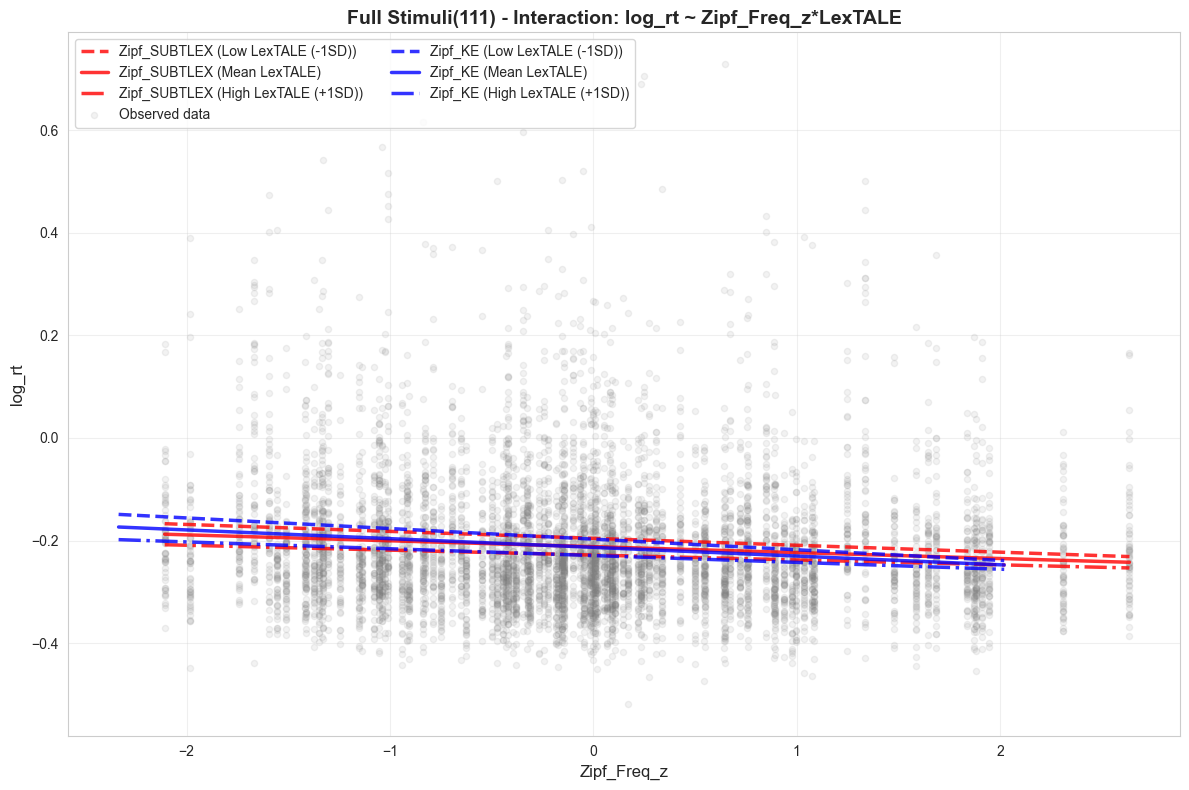

In [177]:
eval_rt_frequency_with_lextale_reg(full_cumulative_df, 'log_rt', ['Zipf_SUBTLEX', 'Zipf_KE'], title='Full Stimuli(111)')

### SUBTLEX Stimuli(60)

model eval metric
--------------------------------
  independent_var          AIC          BIC          NLL  marginal_r2  \
0    Zipf_SUBTLEX -4920.739246 -4877.188893  2467.369623     0.042039   
1         Zipf_KE -4973.426921 -4929.876568  2493.713461     0.052942   

   conditional_r2  
0        0.660453  
1        0.664516  

--- Statsmodels를 이용한 MixedLM 결과 ---
formula: log_rt ~ Zipf_SUBTLEX_z*LexTALE
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    log_rt   
No. Observations:     3720       Method:                ML       
No. Groups:           62         Scale:                 0.0065   
Min. group size:      60         Log-Likelihood:        2467.3696
Max. group size:      60         Converged:             Yes      
Mean group size:      60.0                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------

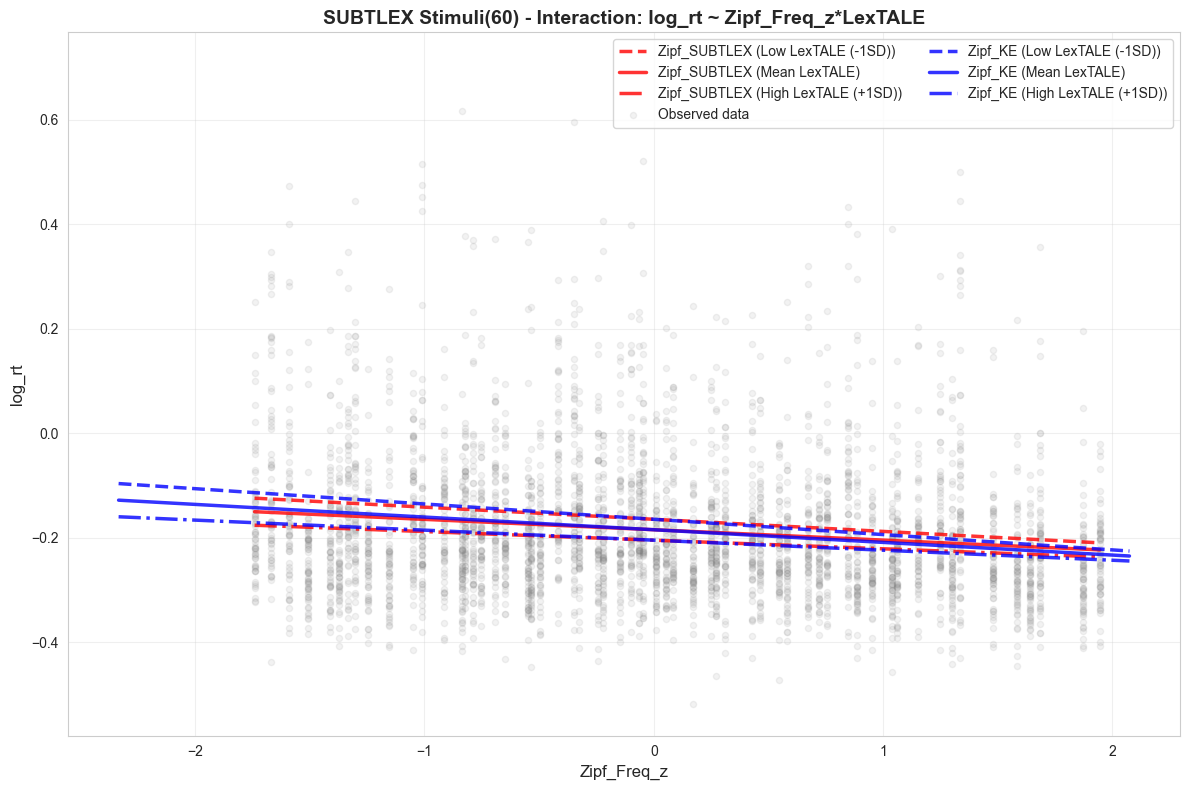

In [178]:
eval_rt_frequency_with_lextale_reg(SUBTLEX_cumulative_df, 'log_rt', ['Zipf_SUBTLEX', 'Zipf_KE'], title='SUBTLEX Stimuli(60)')

### KE Stimuli(60)

model eval metric
--------------------------------
  independent_var          AIC          BIC          NLL  marginal_r2  \
0    Zipf_SUBTLEX -6435.842556 -6392.292204  3224.921278     0.013517   
1         Zipf_KE -6441.458873 -6397.908520  3227.729436     0.014728   

   conditional_r2  
0        0.649987  
1        0.650436  

--- Statsmodels를 이용한 MixedLM 결과 ---
formula: log_rt ~ Zipf_SUBTLEX_z*LexTALE
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    log_rt   
No. Observations:     3720       Method:                ML       
No. Groups:           62         Scale:                 0.0043   
Min. group size:      60         Log-Likelihood:        3224.9213
Max. group size:      60         Converged:             Yes      
Mean group size:      60.0                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------

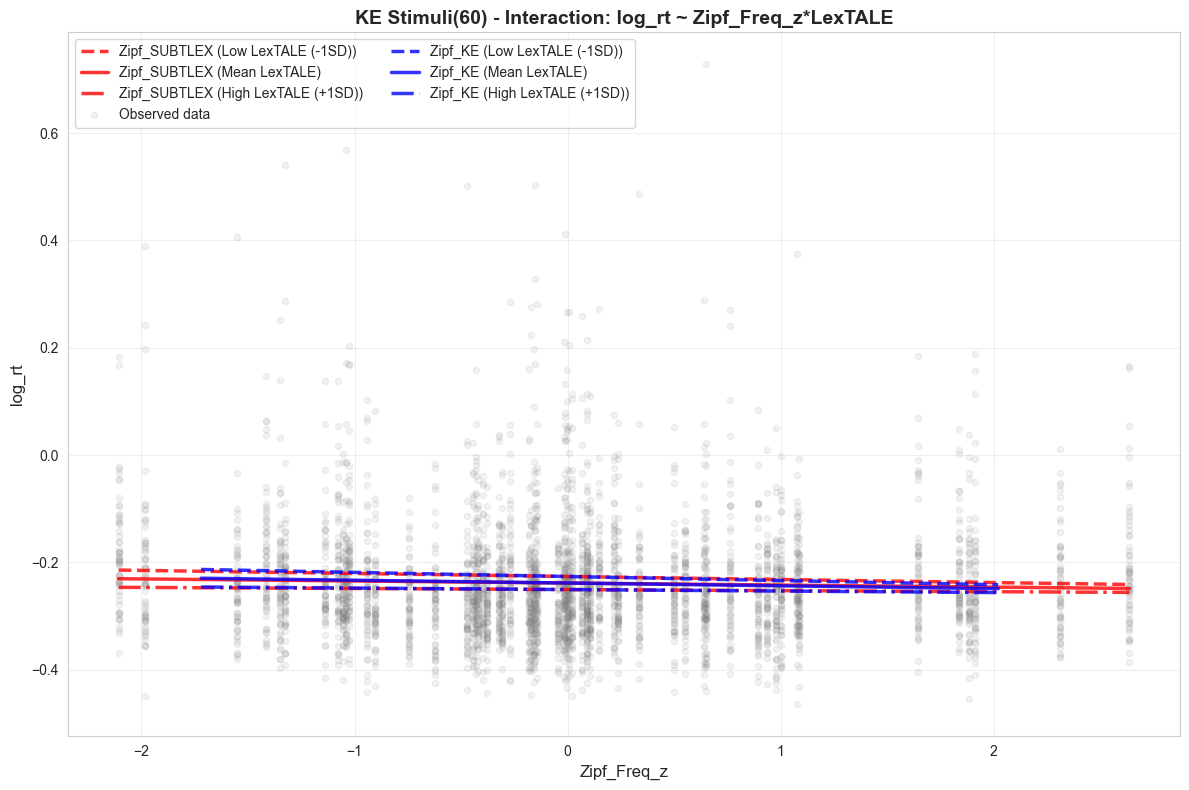

In [179]:
eval_rt_frequency_with_lextale_reg(KE_cumulative_df, 'log_rt', ['Zipf_SUBTLEX', 'Zipf_KE'], title='KE Stimuli(60)')

## KE Freq, SUBLTEX Freq 간에는 Colinearity가 있긴 하겠지만, 같이 넣고 회귀하면 어디에 coeff가 잡히는 가?

In [180]:
# LMM
formula = 'log_rt ~ Zipf_KE_z + Zipf_SUBTLEX_z' # regression formula
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model = MixedLM.from_formula(formula,
    data=full_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit(reml=False)
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
print(f"model.aic: {model.aic}")
print(f"model.bic: {model.bic}")
print("Marginal R2:", mixedlm_r2(model)['R2_marginal'])
print("Conditional R2:", mixedlm_r2(model)['R2_conditional'])

model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---
model.aic: -9902.392806970303
model.bic: -9861.37281945216
Marginal R2: 0.016444629750754496
Conditional R2: 0.6508602982807117


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   6882     Method:              ML       
No. Groups:         62       Scale:               0.0059   
Min. group size:    111      Log-Likelihood:      4957.1964
Max. group size:    111      Converged:           Yes      
Mean group size:    111.0                                  
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -0.213    0.007 -29.902 0.000 -0.227 -0.199
Zipf_KE_z       -0.015    0.002  -8.560 0.000 -0.018 -0.011
Zipf_SUBTLEX_z  -0.005    0.002  -2.883 0.004 -0.008 -0.001
Participant Var  0.003                                     
word Var         0.008                                     
===========================================================

"""

### Residual Analysis

L1 빈도와 L2 빈도는 서로 높은 상관관계(Collinearity)를 가질 것입니다. (영어니까 자주 쓰는 단어는 겹치겠죠). 이 둘을 한 모델에 넣고 누가 살아남는지를 보는 것이 가장 강력한 방법입니다.

하지만 다중공선성(Multicollinearity) 때문에 단순히 둘 다 넣으면 해석이 꼬일 수 있습니다. 이때 사용하는 표준적인 방법이 **잔차화(Residualization)**입니다.

논리: "L1 빈도로는 설명되지 않는, **L2 빈도만의 고유한 정보(Residual)**가 행동 데이터를 예측하는가?"

L2-L1 Residual의 유의성이 반대 케이스보다 더 낮게 잡힘.(p-val) 즉, RT 예측에 있어, L2에서 L1을 제하고 남은 부분을 사용했을 때 더 유의한 회귀를 할 수 있다는 말.

즉, L2에는 L1 정보만으로는 설명할 수 없는 정보가 있음. 그것도 반대 케이스보다 더 의미가 있는

#### L2-L1 Residual

In [183]:
import statsmodels.api as sm

# 1. 잔차 구하기 (단순 선형 회귀)
# L2 빈도를 종속변수, L1 빈도를 독립변수로 둡니다.
X = sm.add_constant(full_cumulative_df['Zipf_SUBTLEX'])
ols_res = sm.OLS(full_cumulative_df['Zipf_KE'], X).fit()
full_cumulative_df['Zipf_KE_Resid'] = ols_res.resid  # 이것이 '순수 L2 빈도'

# 2. LMM 돌리기
# 기존 L1 빈도에 더해, 위에서 구한 잔차를 추가 변수로 넣습니다.
formula = 'log_rt ~ Zipf_SUBTLEX + Zipf_KE_Resid' 
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model_competition = MixedLM.from_formula(formula,
    data=full_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit(reml=False)
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
print(f"model.aic: {model_competition.aic}")
print(f"model.bic: {model_competition.bic}")
print("Marginal R2:", mixedlm_r2(model_competition)['R2_marginal'])
print("Conditional R2:", mixedlm_r2(model_competition)['R2_conditional'])

model_competition.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---
model.aic: -10331.077435540727
model.bic: -10290.057448022582
Marginal R2: 0.06491913278686764
Conditional R2: 0.6688521276890024


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   6882     Method:              ML       
No. Groups:         62       Scale:               0.0056   
Min. group size:    111      Log-Likelihood:      5171.5387
Max. group size:    111      Converged:           Yes      
Mean group size:    111.0                                  
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        0.018    0.014   1.291 0.197 -0.009  0.044
Zipf_SUBTLEX    -0.046    0.002 -19.798 0.000 -0.050 -0.041
Zipf_KE_Resid   -0.047    0.003 -14.163 0.000 -0.053 -0.040
Participant Var  0.003                                     
word Var         0.007                                     
===========================================================

"""

#### L1-L2 Residual

In [184]:
import statsmodels.api as sm

# 1. 잔차 구하기 (단순 선형 회귀)
# L2 빈도를 종속변수, L1 빈도를 독립변수로 둡니다.
X = sm.add_constant(full_cumulative_df['Zipf_KE'])
ols_res = sm.OLS(full_cumulative_df['Zipf_SUBTLEX'], X).fit()
full_cumulative_df['Zipf_SUBTLEX_Resid'] = ols_res.resid  # 이것이 '순수 L2 빈도'

# 2. LMM 돌리기
# 기존 L1 빈도에 더해, 위에서 구한 잔차를 추가 변수로 넣습니다.
formula = 'log_rt ~ Zipf_KE + Zipf_SUBTLEX_Resid' 
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model_competition = MixedLM.from_formula(formula,
    data=full_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit(reml=False)
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
print(f"model.aic: {model_competition.aic}")
print(f"model.bic: {model_competition.bic}")
print("Marginal R2:", mixedlm_r2(model_competition)['R2_marginal'])
print("Conditional R2:", mixedlm_r2(model_competition)['R2_conditional'])

model_competition.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---
model.aic: -10331.077435540741
model.bic: -10290.057448022597
Marginal R2: 0.0649191327868689
Conditional R2: 0.6688521276890009


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:               MixedLM   Dependent Variable:   log_rt   
No. Observations:    6882      Method:               ML       
No. Groups:          62        Scale:                0.0056   
Min. group size:     111       Log-Likelihood:       5171.5387
Max. group size:     111       Converged:            Yes      
Mean group size:     111.0                                    
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           0.054    0.013   4.129 0.000  0.028  0.080
Zipf_KE            -0.052    0.002 -24.246 0.000 -0.057 -0.048
Zipf_SUBTLEX_Resid -0.008    0.004  -2.167 0.030 -0.015 -0.001
Participant Var     0.003                                     
word Var            0.007                                     
==============================================================

"""

# ELP에서 제공하는 L1 Englieh Learner의 RT를 가져와서 분석.

In [192]:
elex_df = pd.read_csv(elex_path)
elex_df.head()
elex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40481 entries, 0 to 40480
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Word                           40480 non-null  object 
 1   Length                         40481 non-null  int64  
 2   Freq_KF                        40481 non-null  object 
 3   Freq_HAL                       40481 non-null  object 
 4   SUBTLWF                        40481 non-null  object 
 5   SUBTLCD                        40481 non-null  object 
 6   Ortho_N                        40481 non-null  int64  
 7   Phono_N                        40481 non-null  int64  
 8   OLD                            40481 non-null  object 
 9   PLD                            40481 non-null  object 
 10  Concreteness_Rating            40481 non-null  object 
 11  Semantic_Neighborhood_Density  40481 non-null  object 
 12  Semantic_Neighbors             40481 non-null 

In [193]:
elex_df.columns

Index(['Word', 'Length', 'Freq_KF', 'Freq_HAL', 'SUBTLWF', 'SUBTLCD',
       'Ortho_N', 'Phono_N', 'OLD', 'PLD', 'Concreteness_Rating',
       'Semantic_Neighborhood_Density', 'Semantic_Neighbors',
       'Semantic_Diversity', 'Age_Of_Acquisition', 'Body_Object_Interaction',
       'Emotional_Valence', 'Emotional_Arousal', 'Emotional_Dominance',
       'Assoc_Freq_R1', 'Assoc_Types_R1', 'Assoc_Freq_R123',
       'Assoc_Types_R123', 'POS', 'I_Mean_RT', 'I_Zscore', 'I_SD', 'Obs',
       'I_Mean_Accuracy', 'I_NMG_Mean_RT', 'I_NMG_Zscore', 'I_NMG_SD',
       'I_NMG_Obs', 'I_NMG_Mean_Accuracy'],
      dtype='object')

In [194]:
target_cols = ['Word', 'I_Mean_RT', 'Obs']

In [195]:
elex_df = elex_df[target_cols]
elex_df['Word'] = elex_df['Word'].str.lower()
elex_df.rename(columns={'Word': 'Stimuli'}, inplace=True)

In [196]:
full_words_df = pd.concat((SUBTLEX_target_df, KE_target_df)).drop_duplicates(subset=['Stimuli'])
elex_df = pd.merge(full_words_df, elex_df, on='Stimuli', how='left')
elex_df

,Stimuli,Length,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX,I_Mean_RT,Obs
0,boss,4,95.564516,20.608899,4.497380,5.093873,595.686,35
1,fall,4,81.854839,21.378387,5.080957,5.073195,549.400,35
2,wake,4,92.137097,22.950820,4.729953,5.021547,588.030,33
3,blue,4,77.217742,23.619940,5.177867,5.009709,573.647,34
4,club,4,64.314516,24.255604,5.370022,4.994123,547.029,34
...,...,...,...,...,...,...,...,...
106,plan,4,75.201613,18.869187,5.214079,5.162975,601.147,34
107,hold,4,75.604839,8.364001,5.207074,5.639600,613.176,34
108,war,3,76.008065,16.761459,5.199954,5.241834,580.719,32
109,pick,4,78.024194,15.289394,5.162492,5.296931,535.031,32


In [197]:
elex_df['I_Mean_RT'] = elex_df['I_Mean_RT'].astype(float)
elex_df['log_rt_l1'] = np.log10(elex_df['I_Mean_RT'])
elex_df

,Stimuli,Length,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX,I_Mean_RT,Obs,log_rt_l1
0,boss,4,95.564516,20.608899,4.497380,5.093873,595.686,35,2.775017
1,fall,4,81.854839,21.378387,5.080957,5.073195,549.400,35,2.739889
2,wake,4,92.137097,22.950820,4.729953,5.021547,588.030,33,2.769399
3,blue,4,77.217742,23.619940,5.177867,5.009709,573.647,34,2.758645
4,club,4,64.314516,24.255604,5.370022,4.994123,547.029,34,2.738010
...,...,...,...,...,...,...,...,...,...
106,plan,4,75.201613,18.869187,5.214079,5.162975,601.147,34,2.778981
107,hold,4,75.604839,8.364001,5.207074,5.639600,613.176,34,2.787585
108,war,3,76.008065,16.761459,5.199954,5.241834,580.719,32,2.763966
109,pick,4,78.024194,15.289394,5.162492,5.296931,535.031,32,2.728379


mean 값들만 있어서 mixedLM을 할 필요가 없음. 개인내 정보가 없으니. ONE-WAY ANOVA가 대안. 

In [198]:
from statsmodels.formula.api import ols

In [199]:
# z-scoring
elex_df['Zipf_SUBTLEX_z'] = zscore(elex_df['Zipf_SUBTLEX'])
elex_df['Zipf_KE_z'] = zscore(elex_df['Zipf_KE'])

개인차에 대한 정보가 없이 단순한 평균만 사용해서 회귀를 시켜서 그런건지, KE가 더 예측을 잘하긴 하는데, $R^2$ 값이 완전 낮음. 별로 의미가 있는 분석이라 보기는 어려움.

In [202]:
# LMM
formula = 'log_rt_l1 ~ Zipf_KE_z' # regression formula
model = ols(formula,
    data=elex_df
    ).fit(reml=False)

print("--- Statsmodels를 이용한 OLS 결과 ---")
model.summary()

--- Statsmodels를 이용한 OLS 결과 ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_rt_l1   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     12.00
Date:                Fri, 28 Nov 2025   Prob (F-statistic):           0.000760
Time:                        23:49:24   Log-Likelihood:                 231.48
No. Observations:                 111   AIC:                            -459.0
Df Residuals:                     109   BIC:                            -453.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7762      0.003    963.958      0.000       2.770       2.782
Zipf_KE_z     -0.0100      0.003     -3.465      0.001      -0.016      -0.004
==============================================================================
Omnibus:                        3.571   Durbin-Watson:                   1.799
Prob(Omnibus):                  0.168   Jarque-Bera (JB):                2.967
Skew:                           0.319   Prob(JB):                        0.227
Kurtosis:                       3.484   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [203]:
# LMM
formula = 'log_rt_l1 ~ Zipf_SUBTLEX_z' # regression formula
model = ols(formula,
    data=elex_df
    ).fit(reml=False)

print("--- Statsmodels를 이용한 OLS 결과 ---")
model.summary()

--- Statsmodels를 이용한 OLS 결과 ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_rt_l1   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     7.109
Date:                Fri, 28 Nov 2025   Prob (F-statistic):            0.00884
Time:                        23:49:24   Log-Likelihood:                 229.18
No. Observations:                 111   AIC:                            -454.4
Df Residuals:                     109   BIC:                            -448.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.7762      0.003    944.261      0.000       2.770       2.782
Zipf_SUBTLEX_z    -0.0078      0.003     -2.666      0.009      -0.014      -0.002
==============================================================================
Omnibus:                        5.015   Durbin-Watson:                   1.814
Prob(Omnibus):                  0.081   Jarque-Bera (JB):                4.655
Skew:                           0.360   Prob(JB):                       0.0975
Kurtosis:                       3.699   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## CV(Cross Validation)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 가정: df에 'log_rt', 'L1_Freq_z', 'L2_Freq_z', 'Participant' 컬럼이 있음

# 1. 설정
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)
rmse_l1 = []
rmse_l2 = []

# 데이터 준비 (결측치 제거 필수)
data = full_cumulative_df.dropna(subset=['log_rt', 'Zipf_KE_z', 'Zipf_SUBTLEX_z', 'Participant']).reset_index(drop=True)

# 2. CV 루프 (참가자 기준으로 분할)
# groups 인자에 Participant를 넣어주는 것이 핵심!
for train_idx, test_idx in gkf.split(data, groups=data['Participant']):
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    # --- Model A: L1 Corpus ---
    # reml=False (ML)로 적합하는 것이 예측 비교에 더 안정적일 수 있음
    model_l1 = smf.mixedlm("log_rt ~ Zipf_SUBTLEX", train_data, groups="Participant").fit(reml=False)
    # 예측 (Test set에는 random effect가 없으므로 고정 효과로만 예측하거나, 평균값 대치)
    # MixedLM predict는 기본적으로 고정 효과만 사용 (allow_new_groups=True 필요할 수 있음)
    pred_l1 = model_l1.predict(test_data.drop(columns=['log_rt']))
    rmse_l1.append(np.sqrt(mean_squared_error(test_data['log_rt'], pred_l1)))

    # --- Model B: L2 Corpus ---
    model_l2 = smf.mixedlm("log_rt ~ Zipf_KE", train_data, groups="Participant").fit(reml=False)
    pred_l2 = model_l2.predict(test_data.drop(columns=['log_rt']))
    rmse_l2.append(np.sqrt(mean_squared_error(test_data['log_rt'], pred_l2)))

# 3. 결과 비교
print(f"Average RMSE (L1 Model): {np.mean(rmse_l1):.4f}")
print(f"Average RMSE (L2 Model): {np.mean(rmse_l2):.4f}")

if np.mean(rmse_l2) < np.mean(rmse_l1):
    print("결론: L2 모델이 새로운 학습자에 대한 예측력이 더 뛰어납니다.")

Average RMSE (L1 Model): 0.1266
Average RMSE (L2 Model): 0.1253
결론: L2 모델이 새로운 학습자에 대한 예측력이 더 뛰어납니다.


In [206]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 가정: df에 'log_rt', 'L1_Freq_z', 'L2_Freq_z', 'Participant' 컬럼이 있음

# 1. 설정
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)
rmse_l1 = []
rmse_l2 = []

# 데이터 준비 (결측치 제거 필수)
data = SUBTLEX_cumulative_df.dropna(subset=['log_rt', 'Zipf_KE_z', 'Zipf_SUBTLEX_z', 'Participant']).reset_index(drop=True)

# 2. CV 루프 (참가자 기준으로 분할)
# groups 인자에 Participant를 넣어주는 것이 핵심!
for train_idx, test_idx in gkf.split(data, groups=data['Participant']):
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    # --- Model A: L1 Corpus ---
    # reml=False (ML)로 적합하는 것이 예측 비교에 더 안정적일 수 있음
    model_l1 = smf.mixedlm("log_rt ~ Zipf_SUBTLEX", train_data, groups="Participant").fit(reml=False)
    # 예측 (Test set에는 random effect가 없으므로 고정 효과로만 예측하거나, 평균값 대치)
    # MixedLM predict는 기본적으로 고정 효과만 사용 (allow_new_groups=True 필요할 수 있음)
    pred_l1 = model_l1.predict(test_data.drop(columns=['log_rt']))
    rmse_l1.append(np.sqrt(mean_squared_error(test_data['log_rt'], pred_l1)))

    # --- Model B: L2 Corpus ---
    model_l2 = smf.mixedlm("log_rt ~ Zipf_KE", train_data, groups="Participant").fit(reml=False)
    pred_l2 = model_l2.predict(test_data.drop(columns=['log_rt']))
    rmse_l2.append(np.sqrt(mean_squared_error(test_data['log_rt'], pred_l2)))

# 3. 결과 비교
print(f"Average RMSE (L1 Model): {np.mean(rmse_l1):.4f}")
print(f"Average RMSE (L2 Model): {np.mean(rmse_l2):.4f}")

if np.mean(rmse_l2) < np.mean(rmse_l1):
    print("결론: L2 모델이 새로운 학습자에 대한 예측력이 더 뛰어납니다.")

Average RMSE (L1 Model): 0.1367
Average RMSE (L2 Model): 0.1361
결론: L2 모델이 새로운 학습자에 대한 예측력이 더 뛰어납니다.


In [207]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 가정: df에 'log_rt', 'L1_Freq_z', 'L2_Freq_z', 'Participant' 컬럼이 있음

# 1. 설정
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)
rmse_l1 = []
rmse_l2 = []

# 데이터 준비 (결측치 제거 필수)
data = KE_cumulative_df.dropna(subset=['log_rt', 'Zipf_KE_z', 'Zipf_SUBTLEX_z', 'Participant']).reset_index(drop=True)

# 2. CV 루프 (참가자 기준으로 분할)
# groups 인자에 Participant를 넣어주는 것이 핵심!
for train_idx, test_idx in gkf.split(data, groups=data['Participant']):
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    # --- Model A: L1 Corpus ---
    # reml=False (ML)로 적합하는 것이 예측 비교에 더 안정적일 수 있음
    model_l1 = smf.mixedlm("log_rt ~ Zipf_SUBTLEX", train_data, groups="Participant").fit(reml=False)
    # 예측 (Test set에는 random effect가 없으므로 고정 효과로만 예측하거나, 평균값 대치)
    # MixedLM predict는 기본적으로 고정 효과만 사용 (allow_new_groups=True 필요할 수 있음)
    pred_l1 = model_l1.predict(test_data.drop(columns=['log_rt']))
    rmse_l1.append(np.sqrt(mean_squared_error(test_data['log_rt'], pred_l1)))

    # --- Model B: L2 Corpus ---
    model_l2 = smf.mixedlm("log_rt ~ Zipf_KE", train_data, groups="Participant").fit(reml=False)
    pred_l2 = model_l2.predict(test_data.drop(columns=['log_rt']))
    rmse_l2.append(np.sqrt(mean_squared_error(test_data['log_rt'], pred_l2)))

# 3. 결과 비교
print(f"Average RMSE (L1 Model): {np.mean(rmse_l1):.4f}")
print(f"Average RMSE (L2 Model): {np.mean(rmse_l2):.4f}")

if np.mean(rmse_l2) < np.mean(rmse_l1):
    print("결론: L2 모델이 새로운 학습자에 대한 예측력이 더 뛰어납니다.")

Average RMSE (L1 Model): 0.1106
Average RMSE (L2 Model): 0.1105
결론: L2 모델이 새로운 학습자에 대한 예측력이 더 뛰어납니다.
